# TEM Tango Control — Client Tutorial

This notebook demonstrates how to connect to and interact with the TEM Tango devices.

All device servers must be running **before** executing this notebook.

Start the HAADF detector:

```bash
uv run python -m tango.test_context asyncroscopy.detectors.HAADF.HAADF --host 127.0.0.1 --port 8888
```


Start the Microscope (in a separate terminal):

```bash
uv run python -m tango.test_context asyncroscopy.Microscope.Microscope --host 127.0.0.1 --port 8889 \
  --prop "{'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no'}"
```

Start the Corrector (in a separate terminal):

```bash
uv run python -m tango.test_context asyncroscopy.hardware.CORRECTOR.CORRECTOR --host 127.0.0.1 --port 8890

```


---

If You Get “Address Already in Use”

It means something is already running on that port (likely from a previous session).

To check what is using a port:

```bash
lsof -i :8888
```

Then kill it using the PID shown:

```bash
kill -9 <PID>
```

Quick one-liner:

```bash
kill -9 $(lsof -t -i:8888)
```

Repeat for port `8889` if needed.

---

If a notebook crashes, `tango.test_context` may continue running in the background.
Always stop the previous process before restarting the device server.




## 1. Connect to devices

In [29]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

import json
import tango

import pyTEMlib
import pyTEMlib.probe_tools as pt
import pyTEMlib.image_tools as it

In [ ]:
# # --nodb mode — use full tango:// URL with port and #dbase=no suffix
# haadf_proxy = tango.DeviceProxy("tango://127.0.0.1:8888/test/nodb/haadf#dbase=no")
# microscope_proxy = tango.DeviceProxy("tango://127.0.0.1:8889/test/nodb/thermomicroscope#dbase=no")

In [2]:
corrector_proxy = tango.DeviceProxy("tango://127.0.0.1:8890/test/nodb/corrector#dbase=no")
corrector_proxy.set_timeout_millis(120_000)
print('Corrector state     :', corrector_proxy.state())

Corrector state     : ON


In [3]:
print('\n--- corrector commands ---')
for cmd in corrector_proxy.get_command_list():
    print(f'  {cmd}')


--- corrector commands ---
  Init
  State
  Status
  acquire_tableau
  correct_aberration
  get_aberrations
  get_info
  reconnect


In [4]:
json.loads(corrector_proxy.get_info())

{'jsonrpc': '2.0',
 'result': {'host': '198.211.143.10',
  'mode': 'STEM',
  'version': 'v1.6-221-gbb906f58',
  'kernelProtocolVersion': [1, 12, 4],
  'currentSetting': 'MC_STEM@200KV',
  'currentLabel': 'calibrated',
  'measurementRange': {'We': 1.5045056039953781e-06,
   'A2': 3.2649862657378947e-05,
   'B2': 1.6324931328689473e-05},
  'correctorType': 'DCORPRIME',
  'kernelVersion': '5-6-373',
  'kernelHexVersion': 329589},
 'id': 1}

In [11]:
ab_msg = corrector_proxy.acquire_tableau('Fast 2')
ab = json.loads(ab_msg)['result']['aberrations']

{'A1': [-8.529014522874928e-09, -6.9067489235429015e-09],
 'A2': [9.306755208967433e-08, 7.425840372703622e-08],
 'B2': [2.105009746362664e-07, -1.2371686921036942e-07],
 'C1': [1.998556195187378e-08, 0.0]}

In [26]:
ab['acceleration_voltage'] = 60e3 # eV
ab['FOV'] = 100 /10 # nm
ab['convergence_angle'] = 3 # mrad
ab['wavelength'] = it.get_wavelength(ab['acceleration_voltage'])

probe, A_k, chi  = pt.get_probe(msg, 512, 512, verbose= True)

Acceleration voltage 60.0kV  => wavelength 4.87pm
0.003


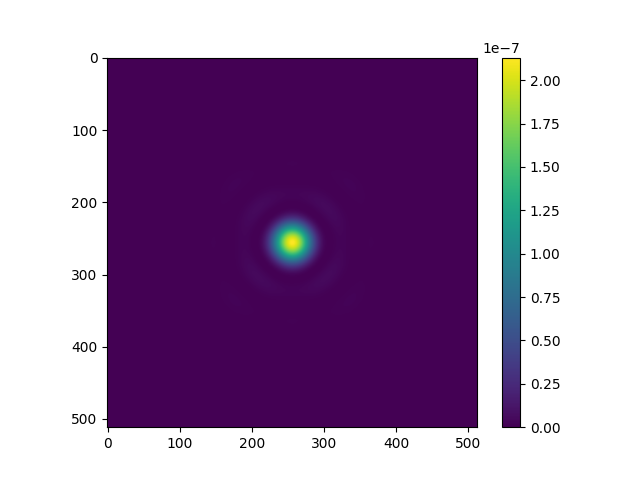

In [28]:
plt.figure()
plt.imshow(probe)
plt.colorbar()